In [1]:
import os
import pandas as pd

source_dir_path = "../datasets/dataset_tang_2017"
os.listdir(source_dir_path)

['Neal',
 'Bike',
 'Concrete',
 'ELE',
 'Diabetes',
 'MPG',
 'Neal_XOutlier',
 'Machine_CPU']

In [2]:
target_dir_path = os.path.join(source_dir_path, "Diabetes")
os.listdir(target_dir_path)

['split_8',
 'split_6',
 'split_0',
 'split_1',
 'split_5',
 'split_4',
 'split_7',
 'split_3',
 'split_2',
 'split_9']

--- Starting Training ---
--- Training Complete ---

Learned hyperparameters:

--- Model Structure ---
SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): RBFKernel(
    (lengthscale_prior): LogNormalPrior()
    (raw_lengthscale_constraint): GreaterThan(2.500E-02)
  )
  (outcome_transform): Standardize()
)
-----------------------
Model uses a base kernel directly (no ScaleKernel).
Kernel lengthscale: 0.2486
Kernel outputscale: N/A (no ScaleKernel wrapper used).
Likelihood noise: 0.0650


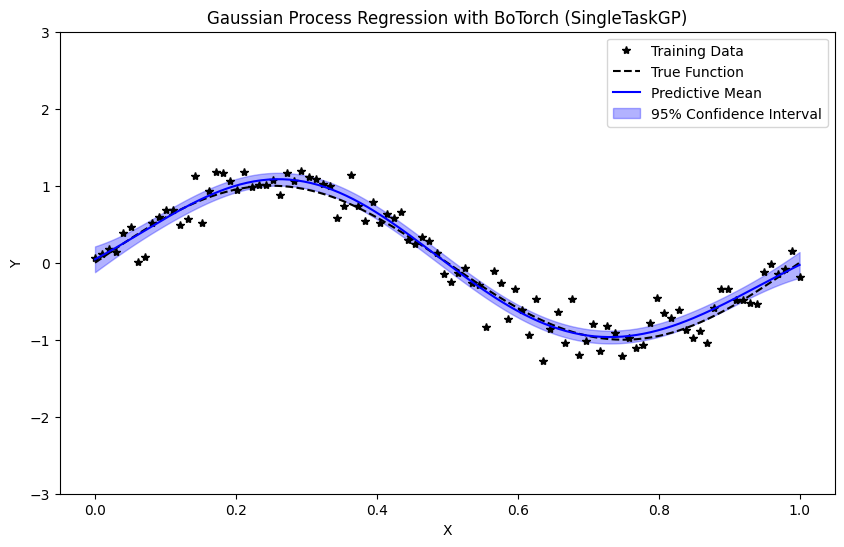

In [4]:
import torch
import gpytorch
import botorch
import math
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Set default tensor type to double precision for BoTorch stability
# This addresses the InputDataWarning
torch.set_default_dtype(torch.double)

# 1. Generate Training Data
train_x_raw = torch.linspace(0, 1, 100)
true_y = torch.sin(train_x_raw * (2 * math.pi))
train_y_raw = true_y + torch.randn(train_x_raw.size()) * 0.2

train_X = train_x_raw.unsqueeze(-1)
train_Y = train_y_raw.unsqueeze(-1)

# 2. Define and Train the GP Model
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

# Let's explicitly specify the kernel to be an RBF kernel to match your environment's behavior.
# This makes the code clearer about the model's structure.
from gpytorch.kernels import RBFKernel

# Define the model. By default, it uses a Matern kernel inside a ScaleKernel.
# We will explicitly create it with an RBF kernel to match your environment's apparent behavior
# and make the code robust.
# model = SingleTaskGP(train_X, train_Y, covar_module=RBFKernel()) # Option 1: Explicit
model = SingleTaskGP(train_X, train_Y) # Option 2: Use default and check structure

mll = ExactMarginalLogLikelihood(model.likelihood, model)

print("--- Starting Training ---")
fit_gpytorch_mll(mll)
print("--- Training Complete ---")


# --- ROBUST HYPERPARAMETER PRINTING ---
print("\nLearned hyperparameters:")

# For debugging, it's always helpful to print the model to see its structure
print("\n--- Model Structure ---")
print(model)
print("-----------------------")

# Check if the covariance module is a ScaleKernel (the common BoTorch default)
# or a base kernel directly (what your environment seems to be doing).
if isinstance(model.covar_module, gpytorch.kernels.ScaleKernel):
    print("Model uses a ScaleKernel wrapper.")
    # Lengthscale is on the base kernel inside the ScaleKernel
    print(f"Kernel lengthscale: {model.covar_module.base_kernel.lengthscale.item():.4f}")
    # Outputscale is on the ScaleKernel itself
    print(f"Kernel outputscale: {model.covar_module.outputscale.item():.4f}")
else:
    # This block will run in your case
    print("Model uses a base kernel directly (no ScaleKernel).")
    # Lengthscale is directly on the covariance module
    print(f"Kernel lengthscale: {model.covar_module.lengthscale.item():.4f}")
    print("Kernel outputscale: N/A (no ScaleKernel wrapper used).")

# The noise is always a parameter of the likelihood
print(f"Likelihood noise: {model.likelihood.noise.item():.4f}")
# --- END ROBUST SECTION ---


# 3. Make Predictions (Inference)
model.eval()
test_x_raw = torch.linspace(0, 1, 200)
test_X = test_x_raw.unsqueeze(-1)

with torch.no_grad():
    posterior = model.posterior(test_X)
    mean = posterior.mean
    variance = posterior.variance.squeeze(-1)
    std_dev = torch.sqrt(variance)
    lower = mean.squeeze(-1) - 1.96 * std_dev
    upper = mean.squeeze(-1) + 1.96 * std_dev

# 4. Plot the Results
with torch.no_grad():
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(train_X.numpy(), train_Y.numpy(), 'k*', label='Training Data')
    ax.plot(test_x_raw.numpy(), torch.sin(test_x_raw * (2 * math.pi)).numpy(), 'k--', label='True Function')
    ax.plot(test_X.numpy(), mean.numpy().squeeze(-1), 'b', label='Predictive Mean')
    ax.fill_between(test_X.numpy().squeeze(-1), lower.numpy(), upper.numpy(), alpha=0.3, color='b', label='95% Confidence Interval')
    ax.set_ylim([-3, 3])
    ax.legend()
    ax.set_title("Gaussian Process Regression with BoTorch (SingleTaskGP)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.show()

# Reset default dtype if you have other code that expects float
torch.set_default_dtype(torch.float)

--- Starting Training with Relevance Pursuit ---
--- Training Complete ---

Injected outlier indices: [10, 30, 55, 70, 90]
Model identified 5 outliers at indices: [10, 30, 55, 70, 90]


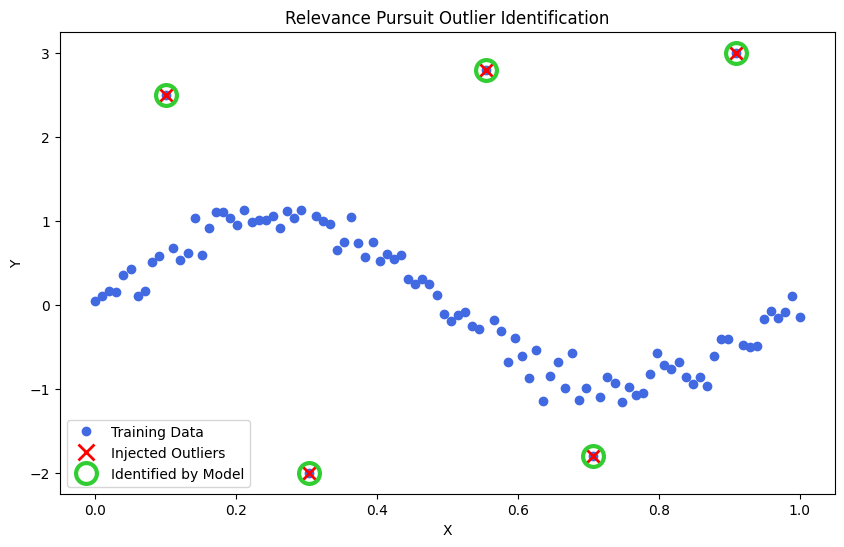

In [6]:
import torch
import math
import matplotlib.pyplot as plt

# 1. Essential Imports
# =====================
from botorch.models.robust_relevance_pursuit_model import RobustRelevancePursuitSingleTaskGP
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

# Set random seed and data type for reproducibility and stability
torch.manual_seed(42)
torch.set_default_dtype(torch.double)


# 2. Generate Data with Outliers
# ===============================
n_points = 100
train_x_raw = torch.linspace(0, 1, n_points)
true_y = torch.sin(train_x_raw * (2 * math.pi))
train_y_raw = true_y + torch.randn(train_x_raw.size()) * 0.15

outlier_indices = torch.tensor([10, 30, 55, 70, 90])
train_y_raw[outlier_indices] = torch.tensor([2.5, -2.0, 2.8, -1.8, 3.0])

train_X = train_x_raw.unsqueeze(-1)
train_Y = train_y_raw.unsqueeze(-1)


# 3. Define and Train the Relevance Pursuit GP Model
# ==================================================
model = RobustRelevancePursuitSingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)

print("--- Starting Training with Relevance Pursuit ---")
fit_gpytorch_mll(mll)
print("--- Training Complete ---")


# 4. Show the Results
# ===================
# --- CORRECTED LINE ---
# `support` is a Python list, so we don't need .detach()
identified_outliers = model.likelihood.noise_covar.support

print(f"\nInjected outlier indices: {outlier_indices.tolist()}")
# We also don't need .tolist() here as it's already a list
print(f"Model identified {len(identified_outliers)} outliers at indices: {identified_outliers}")


# 5. Minimal Plot to Visualize Identified Outliers
# ================================================
# The rest of the code works correctly because a PyTorch tensor can be indexed with a Python list.
plt.figure(figsize=(10, 6))
plt.plot(train_X.numpy(), train_Y.numpy(), 'o', color='royalblue', label='Training Data')
plt.plot(train_X[outlier_indices].numpy(), train_Y[outlier_indices].numpy(), 'rx', markersize=12, mew=2, label='Injected Outliers')

if len(identified_outliers) > 0:
    plt.plot(
        train_X[identified_outliers].numpy(),
        train_Y[identified_outliers].numpy(),
        'o',
        markersize=15,
        markerfacecolor='none',
        markeredgecolor='limegreen',
        mew=3,
        label='Identified by Model'
    )

plt.title("Relevance Pursuit Outlier Identification")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Reset default dtype if other code needs it
torch.set_default_dtype(torch.float)

--- Starting Training (using Approximate Inference) ---
Iter 20/200 - Loss (ELBO): 0.975   lengthscale: 0.808   noise: 0.288   dof: 7.940
Iter 40/200 - Loss (ELBO): 0.540   lengthscale: 0.272   noise: 0.135   dof: 6.442
Iter 60/200 - Loss (ELBO): 0.599   lengthscale: 0.207   noise: 0.101   dof: 3.951
Iter 80/200 - Loss (ELBO): 0.123   lengthscale: 0.199   noise: 0.036   dof: 2.727
Iter 100/200 - Loss (ELBO): -0.001   lengthscale: 0.178   noise: 0.006   dof: 2.242
Iter 120/200 - Loss (ELBO): -0.342   lengthscale: 0.169   noise: 0.007   dof: 2.059
Iter 140/200 - Loss (ELBO): -0.405   lengthscale: 0.169   noise: 0.005   dof: 2.039
Iter 160/200 - Loss (ELBO): -0.407   lengthscale: 0.170   noise: 0.005   dof: 2.028
Iter 180/200 - Loss (ELBO): -0.411   lengthscale: 0.171   noise: 0.005   dof: 2.022
Iter 200/200 - Loss (ELBO): -0.413   lengthscale: 0.170   noise: 0.005   dof: 2.018
--- Training Complete ---

Final learned degrees of freedom (dof): 2.02


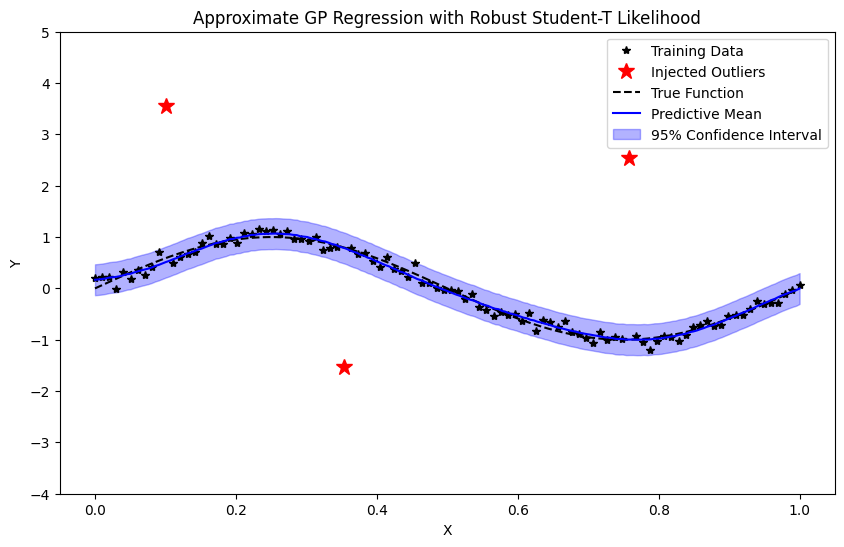

In [41]:
import torch
import gpytorch
import math
import matplotlib.pyplot as plt
from scipy.stats import t # Import the t-distribution from SciPy

# Set random seed for reproducibility
torch.manual_seed(42)

# 1. Generate Training Data with Outliers
n_points = 100
train_x = torch.linspace(0, 1, n_points)
true_y = torch.sin(train_x * (2 * math.pi))
train_y = true_y + torch.randn(train_x.size()) * 0.1
outlier_indices = [10, 35, 75]
train_y[outlier_indices] += torch.tensor([3.0, -2.5, 3.5])

# 2. Define the Approximate GP Model
# num_inducing_points = 20
num_inducing_points = 100  # Increased for better approximation
inducing_points = torch.linspace(0, 1, num_inducing_points)

class ApproximateGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super(ApproximateGPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the model and the Student-T Likelihood separately
likelihood = gpytorch.likelihoods.StudentTLikelihood()
model = ApproximateGPModel(inducing_points)

# 3. Train the Model's Hyperparameters
training_iterations = 200
model.train()
likelihood.train()
optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))

print("--- Starting Training (using Approximate Inference) ---")
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    if (i + 1) % 20 == 0:
        print(f"Iter {i+1}/{training_iterations} - Loss (ELBO): {loss.item():.3f}   "
              f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():.3f}   "
              f"noise: {likelihood.noise.item():.3f}   "
              f"dof: {likelihood.deg_free.item():.3f}")
    optimizer.step()
print("--- Training Complete ---")
print(f"\nFinal learned degrees of freedom (dof): {likelihood.deg_free.item():.2f}")

# 4. Make Predictions (Inference)
model.eval()
likelihood.eval()
test_x = torch.linspace(0, 1, 200)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Because the likelihood is non-conjugate, this returns a distribution containing
    # 10 Monte Carlo samples, giving it a shape of (10, 200)
    observed_pred = likelihood(model(test_x))

# 5. Plot the Results
with torch.no_grad():
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # --- AGGREGATE OVER THE MONTE CARLO SAMPLES ---
    
    # Extract the parameters (all will have shape [10, 200])
    mean_samples = observed_pred.mean
    scale_samples = observed_pred.scale
    df_samples = observed_pred.df
    
    # Get the single scalar degrees_of_freedom value (your brilliant fix)
    degrees_of_freedom = df_samples[0, 0].item()
    critical_value = t.ppf(0.975, df=degrees_of_freedom)
    
    # Construct the interval for each sample path
    margin_samples = critical_value * scale_samples
    lower_samples = mean_samples - margin_samples
    upper_samples = mean_samples + margin_samples
    
    # Aggregate over the sample dimension (dim=0) to get a single line and region to plot
    mean_to_plot = mean_samples.mean(dim=0)
    lower_to_plot = lower_samples.mean(dim=0)
    upper_to_plot = upper_samples.mean(dim=0)
    # --- END CORRECTION ---

    ax.plot(train_x.numpy(), train_y.numpy(), 'k*', label='Training Data')
    ax.plot(train_x[outlier_indices].numpy(), train_y[outlier_indices].numpy(), 'r*', markersize=12, label='Injected Outliers')
    ax.plot(test_x.numpy(), torch.sin(test_x * (2 * math.pi)).numpy(), 'k--', label='True Function')
    
    # Plot the aggregated mean and confidence region
    ax.plot(test_x.numpy(), mean_to_plot.numpy(), 'b', label='Predictive Mean')
    ax.fill_between(test_x.numpy(), lower_to_plot.numpy(), upper_to_plot.numpy(), alpha=0.3, color='b', label='95% Confidence Interval')
    
    ax.set_ylim([-4, 5])
    ax.legend()
    ax.set_title("Approximate GP Regression with Robust Student-T Likelihood")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.show()

--- Starting Training (Sparse Variational GP) ---
Iter 20/200 - Loss (ELBO): 1.728   lengthscale: 0.904   noise: 0.983
Iter 40/200 - Loss (ELBO): 1.081   lengthscale: 0.950   noise: 0.827
Iter 60/200 - Loss (ELBO): 0.867   lengthscale: 0.954   noise: 0.596
Iter 80/200 - Loss (ELBO): 0.734   lengthscale: 0.948   noise: 0.393
Iter 100/200 - Loss (ELBO): 0.655   lengthscale: 0.933   noise: 0.264
Iter 120/200 - Loss (ELBO): 0.619   lengthscale: 0.902   noise: 0.206
Iter 140/200 - Loss (ELBO): 0.577   lengthscale: 0.844   noise: 0.184
Iter 160/200 - Loss (ELBO): 0.489   lengthscale: 0.748   noise: 0.164
Iter 180/200 - Loss (ELBO): 0.851   lengthscale: 0.611   noise: 0.130
Iter 200/200 - Loss (ELBO): 0.653   lengthscale: 0.481   noise: 0.256
--- Training Complete ---


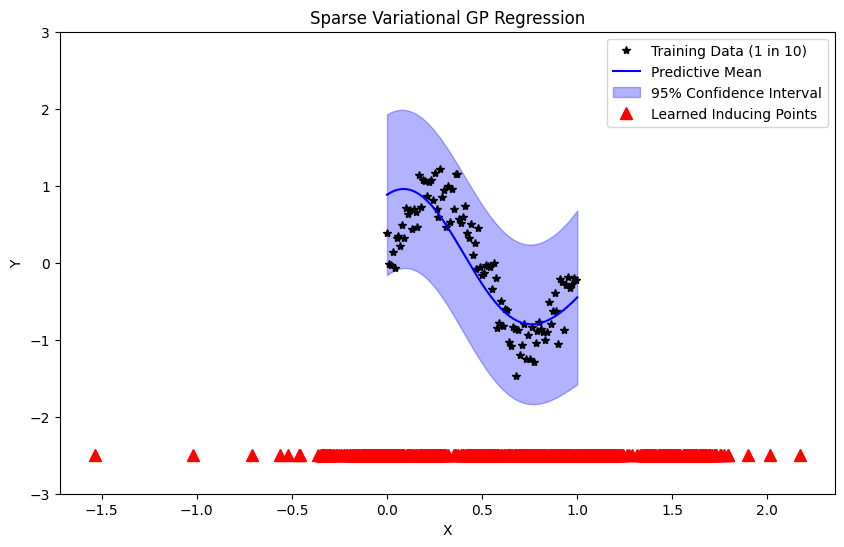

In [45]:
import torch
import gpytorch
import math
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# 1. Generate a Larger Training Dataset
# ======================================
# We use more data points to show why a sparse GP is useful.
# An ExactGP on 1000+ points would be noticeably slow.
n_points = 1000
train_x = torch.linspace(0, 1, n_points)

# True function is a sine wave
true_y = torch.sin(train_x * (2 * math.pi))

# Add standard Gaussian noise
train_y = true_y + torch.randn(train_x.size()) * 0.2


# 2. Define the Sparse Variational GP Model
# =========================================
# The model structure is identical to the one used for the Student-T likelihood.
# The key difference is the likelihood we pair it with.

# We will use m << n inducing points for the sparse approximation.
num_inducing_points = 1000
inducing_points = torch.linspace(0, 1, num_inducing_points)

class ApproximateGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        # We enable learning of the inducing point locations, which is crucial for a good fit.
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super(ApproximateGPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the model and the standard Gaussian Likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ApproximateGPModel(inducing_points)


# 3. Train the Model's Hyperparameters
# ====================================
training_iterations = 200

model.train()
likelihood.train()

# The optimizer includes parameters from both the model and the likelihood
optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)

# The loss function is the Evidence Lower Bound (ELBO)
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))

print("--- Starting Training (Sparse Variational GP) ---")
# Optional: Print initial inducing point locations to see them move
# print("Initial inducing points:\n", model.variational_strategy.inducing_points.data.numpy().flatten())

for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    
    if (i + 1) % 20 == 0:
        print(f"Iter {i+1}/{training_iterations} - Loss (ELBO): {loss.item():.3f}   "
              f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():.3f}   "
              f"noise: {likelihood.noise.item():.3f}")
        
    optimizer.step()

print("--- Training Complete ---")
# Optional: Print final inducing point locations
# print("Optimized inducing points:\n", model.variational_strategy.inducing_points.data.numpy().flatten())


# 4. Make Predictions (Inference)
# ===============================
model.eval()
likelihood.eval()

test_x = torch.linspace(0, 1, 500)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Because we use a GaussianLikelihood, the prediction is analytic (no MC sampling).
    # The returned `observed_pred` is a single MultivariateNormal distribution.
    observed_pred = likelihood(model(test_x))
    

# 5. Plot the Results
# ===================
with torch.no_grad():
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Get the predictive mean and confidence bounds
    mean = observed_pred.mean
    # The .confidence_region() method works again because the posterior is Gaussian!
    lower, upper = observed_pred.confidence_region()

    # Plot a subset of the training data (plotting all 1000 points is messy)
    ax.plot(train_x[::10].numpy(), train_y[::10].numpy(), 'k*', label='Training Data (1 in 10)')
    
    # Plot the predictive mean as a blue line
    ax.plot(test_x.numpy(), mean.numpy(), 'b', label='Predictive Mean')
    
    # Shade the confidence region
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.3, color='b', label='95% Confidence Interval')
    
    # Plot the learned inducing point locations
    inducing_locs = model.variational_strategy.inducing_points.data.numpy()
    ax.plot(inducing_locs, torch.full_like(torch.from_numpy(inducing_locs), -2.5).numpy(), 'r^', markersize=8, label='Learned Inducing Points')

    ax.set_ylim([-3, 3])
    ax.legend(loc='upper right')
    ax.set_title("Sparse Variational GP Regression")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.show()